In [34]:
import os
import requests

from tqdm import tqdm
import matplotlib.pyplot as plt

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

import multiprocessing
multiprocessing.set_start_method('spawn', force=True)

torch.manual_seed(42)
np.random.seed(42)

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [2]:
torch.cuda.empty_cache()

In [3]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
file_path = "tinyshakespeare.txt"

if not os.path.exists(file_path):
    print("Загружаем текст Шекспира...")
    response = requests.get(url)
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(response.text)
    print("Файл сохранён.")

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Загружено {len(text):,} символов.")

Загружено 1,115,394 символов.


In [4]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
# GPT-2 не имеет pad_token по умолчанию — установим его для удобства
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

vocab_size = tokenizer.vocab_size
print(f"🧩 Размер словаря токенизатора: {vocab_size:,} токенов")
print(f"📌 Пример токенизации: '{text[:50]}' -> {tokenizer.encode(text[:50], add_special_tokens=False)[:10]}...")

🧩 Размер словаря токенизатора: 50,257 токенов
📌 Пример токенизации: 'First Citizen:
Before we proceed any further, hear' -> [5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11]...


In [5]:
# ============================================================
# 4. Токенизация всего текста (без специальных токенов)
# ============================================================
print("⏳ Токенизируем весь текст...")
tokens = tokenizer.encode(text, add_special_tokens=False)  # список целых чисел
print(f"✅ Получено {len(tokens):,} токенов.")

⏳ Токенизируем весь текст...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (338025 > 1024). Running this sequence through the model will result in indexing errors


✅ Получено 338,025 токенов.


## Создание датасета для авторегрессивного обучения

In [6]:
# ============================================================
# 5. Создание датасета для авторегрессивного обучения
# ============================================================
class TokenDataset(Dataset):
    def __init__(self, token_list, block_size):
        # Храним на CPU — память экономится, а GPU загружается только батчами
        self.data = torch.tensor(token_list, dtype=torch.long)  # без .to(device)
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.block_size]
        y = self.data[idx + 1:idx + self.block_size + 1]
        return x, y

In [35]:
# Параметры
block_size = 64   # длина контекста (можно менять)
batch_size = 32

# Разбивка на train / val (90% / 10%)
split_idx = int(0.9 * len(tokens))
train_tokens = tokens[:split_idx]
val_tokens = tokens[split_idx:]

train_dataset = TokenDataset(train_tokens, block_size)
val_dataset = TokenDataset(val_tokens, block_size)

print(f"📊 Обучающих примеров: {len(train_dataset):,}")
print(f"📊 Валидационных примеров: {len(val_dataset):,}")

📊 Обучающих примеров: 304,158
📊 Валидационных примеров: 33,739


In [45]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    pin_memory=True,
    num_workers=0          # <- вместо 4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=True,
    pin_memory=True,
    num_workers=0          # <- вместо 4
)

## Реализация троичного линейного слоя QLinear

In [38]:
def modified_weight_quant(w):
    """Квантизация весов до {-1, 0, 1}"""
    return w.clamp(-1, 1).round()

class QLinear(nn.Linear):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.scales = nn.Parameter(torch.ones(self.out_features))
        self.quantizer = modified_weight_quant

    def forward(self, x):
        w_quant = self.weight + (self.quantizer(self.weight) - self.weight).detach()
        y = F.linear(x, w_quant)
        y = y * self.scales
        if self.bias is not None:
            y = y + self.bias
        return y

## Архитектура модели — StandardTransformer

In [39]:
class StandardSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.head_dim = embed_dim // num_heads
        self.num_heads = num_heads

        self.q_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.k_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.v_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.out_proj = nn.Linear(embed_dim, embed_dim, bias=False)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, C = x.shape

        q = self.q_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        if mask is not None:
            att = att.masked_fill(mask == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        out = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        out = self.out_proj(out)
        return out

class StandardTransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = StandardSelfAttention(embed_dim, num_heads, dropout)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim, bias=False),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim, bias=False),
            nn.Dropout(dropout)
        )

    def forward(self, x, mask=None):
        x = x + self.attn(self.ln1(x), mask)
        x = x + self.ff(self.ln2(x))
        return x

class StandardTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_dim, max_seq_len, dropout=0.1):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_embedding = nn.Embedding(max_seq_len, embed_dim)
        self.blocks = nn.ModuleList([
            StandardTransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.ln_f = nn.LayerNorm(embed_dim)
        self.lm_head = nn.Linear(embed_dim, vocab_size, bias=False)

    def forward(self, idx, mask=None):
        B, T = idx.shape
        pos = torch.arange(0, T, device=idx.device).unsqueeze(0).expand(B, T)
        x = self.token_embedding(idx) + self.pos_embedding(pos)

        for block in self.blocks:
            x = block(x, mask)

        x = self.ln_f(x)
        logits = self.lm_head(x)
        return logits

## Архитектура модели — TernaryTransformer

In [40]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.head_dim = embed_dim // num_heads
        self.num_heads = num_heads

        self.q_proj = QLinear(embed_dim, embed_dim, bias=False)
        self.k_proj = QLinear(embed_dim, embed_dim, bias=False)
        self.v_proj = QLinear(embed_dim, embed_dim, bias=False)
        self.out_proj = QLinear(embed_dim, embed_dim, bias=False)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, C = x.shape

        q = self.q_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1,2)
        k = self.k_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1,2)
        v = self.v_proj(x).view(B, T, self.num_heads, self.head_dim).transpose(1,2)

        att = (q @ k.transpose(-2,-1)) / (self.head_dim ** 0.5)
        if mask is not None:
            att = att.masked_fill(mask == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        out = (att @ v).transpose(1,2).contiguous().view(B, T, C)
        out = self.out_proj(out)
        return out

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = SelfAttention(embed_dim, num_heads, dropout)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            QLinear(embed_dim, ff_dim, bias=False),
            nn.GELU(),
            QLinear(ff_dim, embed_dim, bias=False),
            nn.Dropout(dropout)
        )

    def forward(self, x, mask=None):
        x = x + self.attn(self.ln1(x), mask)
        x = x + self.ff(self.ln2(x))
        return x

class TernaryTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_dim, max_seq_len, dropout=0.1):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_embedding = nn.Embedding(max_seq_len, embed_dim)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.ln_f = nn.LayerNorm(embed_dim)
        self.lm_head = nn.Linear(embed_dim, vocab_size, bias=False)  # полноточный

    def forward(self, idx, mask=None):
        B, T = idx.shape
        pos = torch.arange(0, T, device=idx.device).unsqueeze(0).expand(B, T)
        x = self.token_embedding(idx) + self.pos_embedding(pos)

        for block in self.blocks:
            x = block(x, mask)

        x = self.ln_f(x)
        logits = self.lm_head(x)
        return logits

## Обучение

In [58]:
from torch.amp import autocast, GradScaler

def train_epoch(model, train_loader, optimizer, criterion, device, scaler):
    model.train()
    total_loss = 0
    for x, y in tqdm(train_loader, desc="Training", leave=False):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast(device_type="cuda"):
            logits = model(x)
            loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(train_loader.dataset)

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in tqdm(val_loader, desc="Validating", leave=False):
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
            total_loss += loss.item() * x.size(0)
    return total_loss / len(val_loader.dataset)

## Инициализация моделей

In [62]:
epochs = 2
learning_rate = 1e-3

# Функция потерь
criterion = nn.CrossEntropyLoss()

# Общие параметры
embed_dim = 128
num_heads = 4
num_layers = 3
ff_dim = 256
dropout = 0.1

# Тернарная модель
model_ternary = TernaryTransformer(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    ff_dim=ff_dim,
    max_seq_len=block_size,
    dropout=dropout
).to(device)

# Стандартная модель
model_standard = StandardTransformer(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    ff_dim=ff_dim,
    max_seq_len=block_size,
    dropout=dropout
).to(device)

print(f"Тернарная модель: {sum(p.numel() for p in model_ternary.parameters()):,} параметров")
print(f"Стандартная модель: {sum(p.numel() for p in model_standard.parameters()):,} параметров")

Тернарная модель: 13,271,680 параметров
Стандартная модель: 13,268,992 параметров


In [63]:
def train_model(model, model_name, epochs, lr):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = GradScaler()
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(1, epochs+1):
        print(f"\nEpoch {epoch}/{epochs} - {model_name}")
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device, scaler)
        val_loss = evaluate(model, val_loader, criterion, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()

        torch.cuda.empty_cache()

    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses

In [64]:
# Обучаем стандартную модель
print("="*50)
print("Обучение СТАНДАРТНОЙ модели")
model_standard, train_losses_standard, val_losses_standard = train_model(
    model_standard, "Standard", epochs, learning_rate
)

Обучение СТАНДАРТНОЙ модели

Epoch 1/2 - Standard


Train loss: 0.2964, Val loss: 0.5278

Epoch 2/2 - Standard


Train loss: 0.0697, Val loss: 0.6663


In [65]:
# Обучаем тернарную модель
print("="*50)
print("Обучение ТЕРНАРНОЙ модели")
model_ternary, train_losses_ternary, val_losses_ternary = train_model(
    model_ternary, "Ternary", epochs, learning_rate
)

Обучение ТЕРНАРНОЙ модели

Epoch 1/2 - Ternary


Train loss: 3.9568, Val loss: 5.7051

Epoch 2/2 - Ternary


Train loss: 3.5364, Val loss: 5.9251


## Визуализация

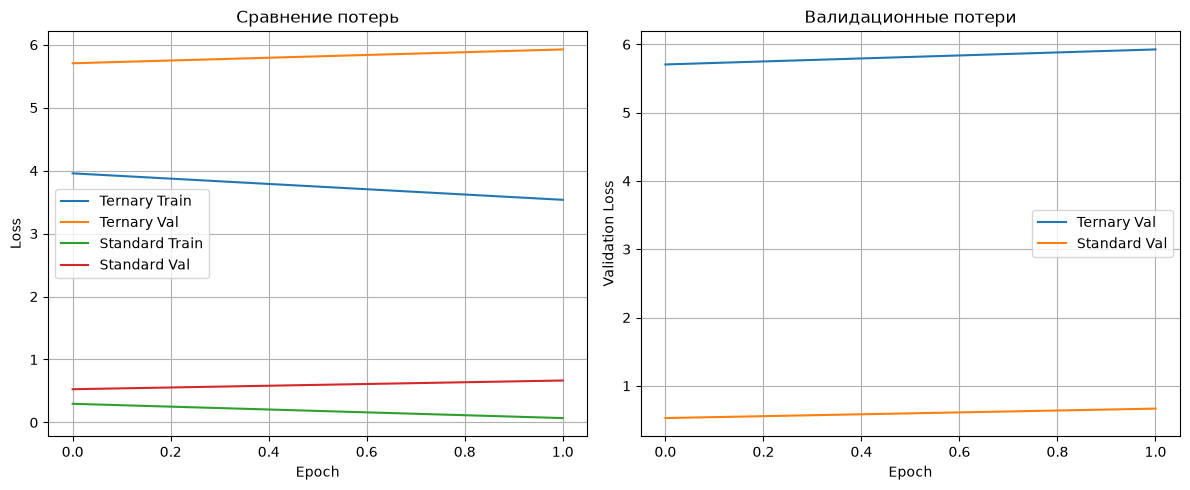

In [66]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_ternary, label='Ternary Train')
plt.plot(val_losses_ternary, label='Ternary Val')
plt.plot(train_losses_standard, label='Standard Train')
plt.plot(val_losses_standard, label='Standard Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Сравнение потерь')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_losses_ternary, label='Ternary Val')
plt.plot(val_losses_standard, label='Standard Val')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Валидационные потери')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Сравнение количества параметров и размера моделей

In [67]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def count_ternary_bits(model):
    # Для тернарной модели считаем биты: каждый вес в QLinear занимает ~1.58 бит + масштабы (32 бита каждый)
    # Упрощённо: считаем все параметры, но для QLinear вес хранится как float, но на самом деле сжат.
    # Для демонстрации просто посчитаем число параметров в QLinear и nn.Linear отдельно.
    qlinear_params = 0
    linear_params = 0
    for name, module in model.named_modules():
        if isinstance(module, QLinear):
            qlinear_params += module.weight.numel()  # полноточная копия, но в реальности сжата
        elif isinstance(module, nn.Linear):
            linear_params += module.weight.numel()
    total = qlinear_params + linear_params
    # Реальный размер: вес QLinear можно хранить в 2 бита (1.58) + масштабы (32 бита каждый)
    # Для оценки: количество масштабов = out_features каждого QLinear
    # Упростим: просто посчитаем биты: каждый вес QLinear ~2 бита, каждый масштаб ~32 бита
    return total

print(f"Параметров в тернарной модели: {sum(p.numel() for p in model_ternary.parameters()):,}")
print(f"Параметров в стандартной модели: {sum(p.numel() for p in model_standard.parameters()):,}")

Параметров в тернарной модели: 13,271,680
Параметров в стандартной модели: 13,268,992


In [68]:
def model_memory_usage(model, device):
    """Возвращает размер модели в байтах (параметры + буферы)"""
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    return param_size + buffer_size

def count_ternary_compressed_size(model):
    """
    Считает размер тернарной модели после сжатия весов QLinear до 2 бит.
    Возвращает размер в байтах.
    """
    qlinear_weights = 0   # количество весов в QLinear (будут сжаты)
    qlinear_scales = 0    # количество scales (остаются float32)
    other_params = 0      # все остальные параметры (embedding, norm, lm_head и т.д.)

    for name, module in model.named_modules():
        if isinstance(module, QLinear):
            qlinear_weights += module.weight.numel()
            qlinear_scales += module.scales.numel()
        else:
            # Считаем все параметры этого модуля (рекурсивно не идём, чтобы не дублировать)
            for p in module.parameters(recurse=False):
                other_params += p.numel()

    # Веса QLinear: 2 бита = 0.25 байта на параметр
    # Scales: float32 = 4 байта
    # Остальное: float32 = 4 байта
    size_bytes = (qlinear_weights * 0.25) + (qlinear_scales * 4) + (other_params * 4)
    return size_bytes

# Текущий размер в памяти (float32 для всех параметров)
standard_size_bytes = model_memory_usage(model_standard, device)
ternary_size_bytes = model_memory_usage(model_ternary, device)

# Размер тернарной после сжатия
ternary_compressed_bytes = count_ternary_compressed_size(model_ternary)

print("="*50)
print("РАЗМЕР МОДЕЛЕЙ В ПАМЯТИ")
print("="*50)
print(f"Стандартная модель (float32):   {standard_size_bytes / (1024**2):.2f} MB")
print(f"Тернарная модель (float32):     {ternary_size_bytes / (1024**2):.2f} MB")
print(f"Тернарная модель (после сжатия):{ternary_compressed_bytes / (1024**2):.2f} MB")
print(f"Сжатие относительно float32:    {ternary_size_bytes / ternary_compressed_bytes:.1f}x")
print(f"Экономия памяти:                {(1 - ternary_compressed_bytes / standard_size_bytes)*100:.1f}%")

РАЗМЕР МОДЕЛЕЙ В ПАМЯТИ
Стандартная модель (float32):   50.62 MB
Тернарная модель (float32):     50.63 MB
Тернарная модель (после сжатия):49.22 MB
Сжатие относительно float32:    1.0x
Экономия памяти:                2.8%


In [69]:
# Сравнение финальных потерь
print("="*50)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*50)
print(f"Стандартная модель - финальный train loss: {train_losses_standard[-1]:.4f}, val loss: {val_losses_standard[-1]:.4f}")
print(f"Тернарная модель   - финальный train loss: {train_losses_ternary[-1]:.4f}, val loss: {val_losses_ternary[-1]:.4f}")
print(f"Отношение val loss (стандартная/тернарная): {val_losses_standard[-1] / val_losses_ternary[-1]:.3f}")

СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Стандартная модель - финальный train loss: 0.0697, val loss: 0.6663
Тернарная модель   - финальный train loss: 3.5364, val loss: 5.9251
Отношение val loss (стандартная/тернарная): 0.112


In [70]:
def generate_text(model, tokenizer, prompt, length=50, temperature=0.8):
    model.eval()
    input_ids = tokenizer.encode(prompt, add_special_tokens=False)
    idx = torch.tensor(input_ids, dtype=torch.long, device=device).unsqueeze(0)
    for _ in range(length):
        logits = model(idx[:, -block_size:])
        logits = logits[0, -1, :] / temperature
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, 1)
        idx = torch.cat([idx, next_token.unsqueeze(0)], dim=1)
    return tokenizer.decode(idx[0].tolist(), skip_special_tokens=True)

prompt = "To be, or not to be,"
print("Стандартная модель:")
print(generate_text(model_standard, tokenizer, prompt, length=80))
print("\nТернарная модель:")
print(generate_text(model_ternary, tokenizer, prompt, length=80))

Стандартная модель:
To be, or not to be, to be to not to to to be to to to to be to to to to to to to to to to to to be to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to to

Тернарная модель:
To be, or not to be, that suck'd
And you, cousin, good friend

Shall darkly o'er the east an

I am a fortnight and that thou sprang not, so bad,

And,
JOHN OF GAUNT:



DUCHESS OVERDUKE OF YORK:

Ere's moiety.
He's rights and to her,


In [74]:
print(generate_text(model_standard, tokenizer, "hi", length=80))

hi many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many many


In [75]:
print(generate_text(model_ternary, tokenizer, "hi", length=80))

hi'st thou livest; I; let it.
The warrants, take the Vols, but kill'd

And you walk'd not do it on my masters, as you.
A:
Then would do it is old.

Her liege,
GLOUCESTER:

MENENRY VI:


How many's blood.



